# PROJECT PART 2


👤 Student 2: Advanced Transformer Model (Sentiment & Topic)
Coding Task: * Work on Sentiment-topic-test.tsv (this fulfills the requirement of comparing 2 different systems).

Implement a Deep Learning / Transformer approach using pre-trained models from Hugging Face (e.g., a CardiffNLP RoBERTa model for sentiment and a Zero-Shot classification or BERT model for topics).

Run predictions on the test set, calculate metrics (Accuracy, F1-Score), and generate plots.

Poster Writing Task: * Write the methodology section for the Transformer approach.

Provide a qualitative analysis of your results with 2 examples of misclassifications.

Write a short comparative paragraph comparing your results against Student 1’s baseline (why Deep Learning outperformed or underperformed the traditional model).

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import csv
from transformers import pipeline
import seaborn as sns

import warnings

# SENTIMENT ANALYSIS - CardiffNLP RoBERTa

In [50]:
## -- SENTIMENT ANALYSIS USING HUGGINGFACE ROBERTA -- ##

LABELS = ["negative", "neutral", "positive"]

# Load the pre-trained RoBERTa model
print("Loading RoBERTa sentiment model (downloads on first run)...")
classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
)
print("Model loaded.\n")

# Load test data from TSV
TSV_PATH = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\Sentiment-topic-test.tsv"

test_data = []
with open(TSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        test_data.append({
            "id":             int(row["sentence id"]),
            "text":           row["text"],
            "true_sentiment": row["sentiment"],
            "topic":          row["topic"],
        })

# Run predictions and evaluate
results = []
y_true, y_pred, confidences = [], [], []

HEADER = f"{'ID':<4} {'Topic':<12} {'True':<10} {'Predicted':<10} {'Confidence':<12} {'Match'}"
print(HEADER)
print("─" * len(HEADER))

for item in test_data:
    output     = classifier(item["text"])[0]
    pred_label = output["label"].lower()
    confidence = output["score"]
    true_label = item["true_sentiment"]
    match      = pred_label == true_label

    y_true.append(true_label)
    y_pred.append(pred_label)
    confidences.append(confidence)

    results.append({
        "id":                  item["id"],
        "text":                item["text"],
        "topic":               item["topic"],
        "true_sentiment":      true_label,
        "predicted_sentiment": pred_label,
        "confidence":          round(confidence, 4),
        "correct":             match,
    })

    tick = "✓" if match else "✗"
    print(f"{item['id']:<4} {item['topic']:<12} {true_label:<10} {pred_label:<10} {confidence:<12.4f} {tick}")

# Evaluation metrics
accuracy      = accuracy_score(y_true, y_pred)
f1_macro      = f1_score(y_true, y_pred, average="macro",    labels=LABELS, zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average="weighted", labels=LABELS, zero_division=0)
f1_per_class  = f1_score(y_true, y_pred, average=None,       labels=LABELS, zero_division=0)

print(f"\n{'─'*45}")
print(f"  Accuracy          : {accuracy:.4f}  ({accuracy:.1%})")
print(f"  F1 (macro)        : {f1_macro:.4f}")
print(f"  F1 (weighted)     : {f1_weighted:.4f}")
for label, score in zip(LABELS, f1_per_class):
    print(f"  F1 [{label:<8}]  : {score:.4f}")
print(f"{'─'*45}\n")
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# Save results to TSV
output_path = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\sentiment_predictions.tsv"
fieldnames  = ["id", "text", "topic", "true_sentiment", "predicted_sentiment", "confidence", "correct"]
with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter="\t")
    writer.writeheader()
    writer.writerows(results)
print(f"Predictions saved → {output_path}")



Loading RoBERTa sentiment model (downloads on first run)...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Model loaded.

ID   Topic        True       Predicted  Confidence   Match
──────────────────────────────────────────────────────────
0    movie        negative   negative   0.8868       ✓
1    restaurant   positive   positive   0.9825       ✓
2    restaurant   negative   negative   0.5751       ✓
3    book         positive   positive   0.8495       ✓
4    movie        neutral    neutral    0.8594       ✓
5    movie        neutral    neutral    0.8209       ✓
6    restaurant   positive   positive   0.9704       ✓
7    movie        positive   positive   0.9708       ✓
8    movie        neutral    neutral    0.9279       ✓
9    book         negative   negative   0.6265       ✓

─────────────────────────────────────────────
  Accuracy          : 1.0000  (100.0%)
  F1 (macro)        : 1.0000
  F1 (weighted)     : 1.0000
  F1 [negative]  : 1.0000
  F1 [neutral ]  : 1.0000
  F1 [positive]  : 1.0000
─────────────────────────────────────────────

              precision    recall  f1-score   su

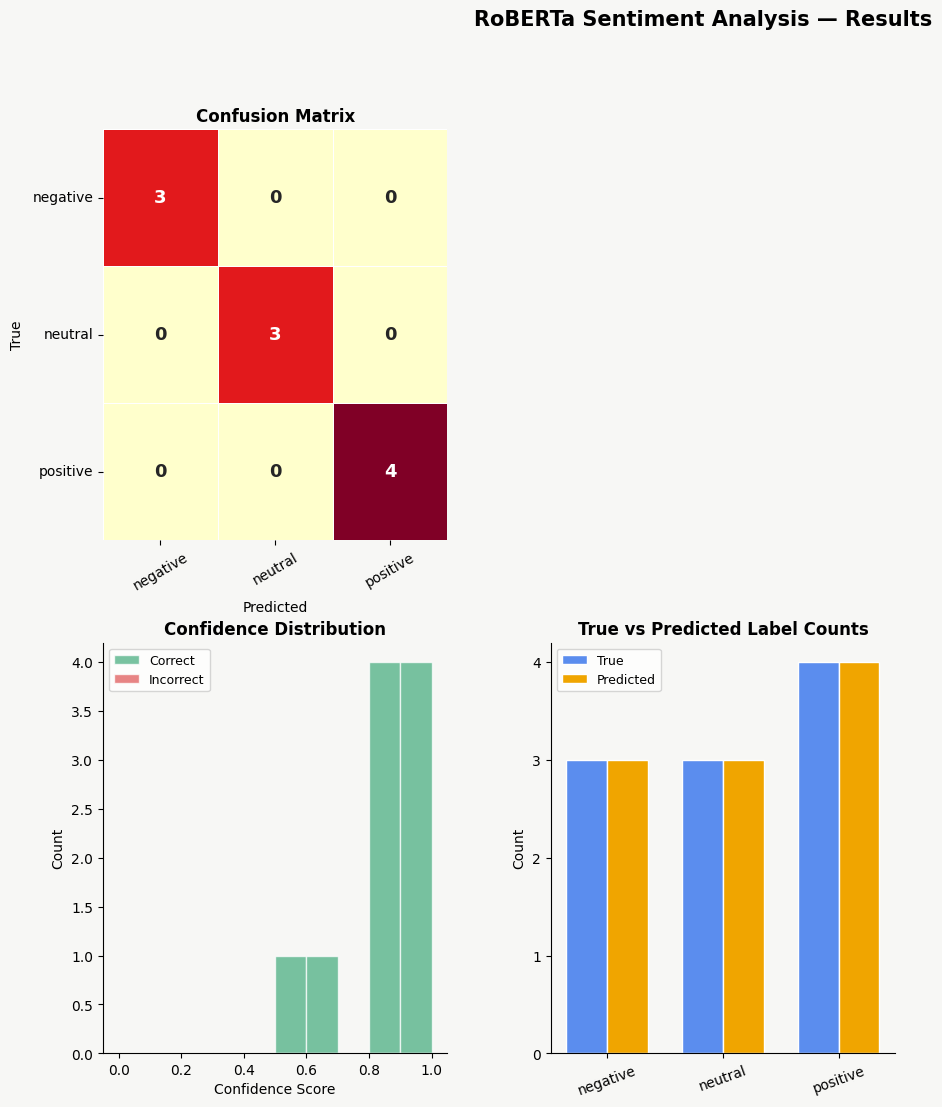

Plot saved → C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\sentiment_results.png


In [51]:
# Plotting results
PALETTE   = {"negative": "#e05c5c", "neutral": "#f0a500", "positive": "#4caf82"}
FIG_COLOR = "#f7f7f5"

fig = plt.figure(figsize=(16, 12), facecolor=FIG_COLOR)
fig.suptitle("RoBERTa Sentiment Analysis — Results", fontsize=15, fontweight="bold", y=0.98)

gs = fig.add_gridspec(2, 3, hspace=0.25, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])   # Confusion matrix
ax2 = fig.add_subplot(gs[1, 0])   # Confidence distribution
ax3 = fig.add_subplot(gs[1, 1])   # True label distribution

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(FIG_COLOR)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=LABELS, yticklabels=LABELS,
    linewidths=0.5, ax=ax1, cbar=False,
    annot_kws={"size": 13, "weight": "bold"}
)
ax1.set_title("Confusion Matrix", fontweight="bold")
ax1.set_xlabel("Predicted", labelpad=6)
ax1.set_ylabel("True", labelpad=6)
ax1.tick_params(axis="x", rotation=30)
ax1.tick_params(axis="y", rotation=0)

# Confidence Distribution
correct_conf   = [r["confidence"] for r in results if r["correct"]]
incorrect_conf = [r["confidence"] for r in results if not r["correct"]]
bins = np.linspace(0, 1, 11)
ax2.hist(correct_conf,   bins=bins, alpha=0.75, color="#4caf82", label="Correct",   edgecolor="white")
ax2.hist(incorrect_conf, bins=bins, alpha=0.75, color="#e05c5c", label="Incorrect", edgecolor="white")
ax2.set_title("Confidence Distribution", fontweight="bold")
ax2.set_xlabel("Confidence Score")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
sns.despine(ax=ax2)

# True vs Predicted Label Counts
x        = np.arange(len(LABELS))
width    = 0.35
true_counts = [y_true.count(l) for l in LABELS]
pred_counts = [y_pred.count(l) for l in LABELS]
ax3.bar(x - width/2, true_counts, width, label="True",      color="#5b8dee", edgecolor="white")
ax3.bar(x + width/2, pred_counts, width, label="Predicted", color="#f0a500", edgecolor="white")
ax3.set_xticks(x)
ax3.set_xticklabels(LABELS, rotation=20)
ax3.set_title("True vs Predicted Label Counts", fontweight="bold")
ax3.set_ylabel("Count")
ax3.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax3.legend(fontsize=9)
sns.despine(ax=ax3)


# Save and show plots
plot_path = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\sentiment_results.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight", facecolor=FIG_COLOR)
plt.show()
print(f"Plot saved → {plot_path}")

# TOPIC CLASSIFICATION - Zero-Shot Classifier

In [52]:

# Ignore warnings for cleaner output
warnings.filterwarnings("ignore")

# Load test data for topic classification
TEST_PATH = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\Sentiment-topic-test.tsv"
test_df = pd.read_csv(TEST_PATH, sep="\t")

# Load zero-shot classifier (BERT-based, fine-tuned on NLI)
classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1       # CPU; set device=0 for GPU
)


TOPIC_LABELS = ["movie", "restaurant", "book"]


# Run predictions
sentences = test_df["text"].tolist()
results = classifier(sentences, candidate_labels=TOPIC_LABELS)

# Store and print predicted topic and confidence score
test_df["predicted_topic"]       = [r["labels"][0] for r in results]
test_df["predicted_topic_score"] = [round(r["scores"][0], 4) for r in results]

for label in TOPIC_LABELS:
    test_df[f"score_{label}"] = [
        round(r["scores"][r["labels"].index(label)], 4)
        for r in results
    ]

print("Predictions vs Ground Truth:")
print(test_df[["text", "topic", "predicted_topic", "predicted_topic_score"]].to_string())

# Evaluation metrics for topic classification
y_true = test_df["topic"].str.lower().tolist()
y_pred = test_df["predicted_topic"].str.lower().tolist()

accuracy    = accuracy_score(y_true, y_pred)
f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0, labels=TOPIC_LABELS)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0, labels=TOPIC_LABELS)
f1_per_class = f1_score(y_true, y_pred, average=None,      zero_division=0, labels=TOPIC_LABELS)

print("\nFull classification report:")
print(classification_report(y_true, y_pred, target_names=TOPIC_LABELS, zero_division=0))


# Save predictions to TSV
OUTPUT_PATH = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\topic_predictions.tsv"
test_df.to_csv(OUTPUT_PATH, sep="\t", index=False)

print(f"Predictions saved → {OUTPUT_PATH}")

Device set to use cpu


Predictions vs Ground Truth:
                                                                                                                                                    text       topic predicted_topic  predicted_topic_score
0                                                              It took eight years for Warner Brothers to recover from the disaster that was this movie.       movie           movie                 0.9941
1                                                   All the New York University students love this diner in Soho so it makes for a fun young atmosphere.  restaurant      restaurant                 0.9869
2                                   This Italian place is really trendy but they have forgotten about the most important part of a restaurant, the food.  restaurant      restaurant                 0.9824
3                                                   In conclusion, my review of this book would be: I like Jane Austen and understand why she is famous.   

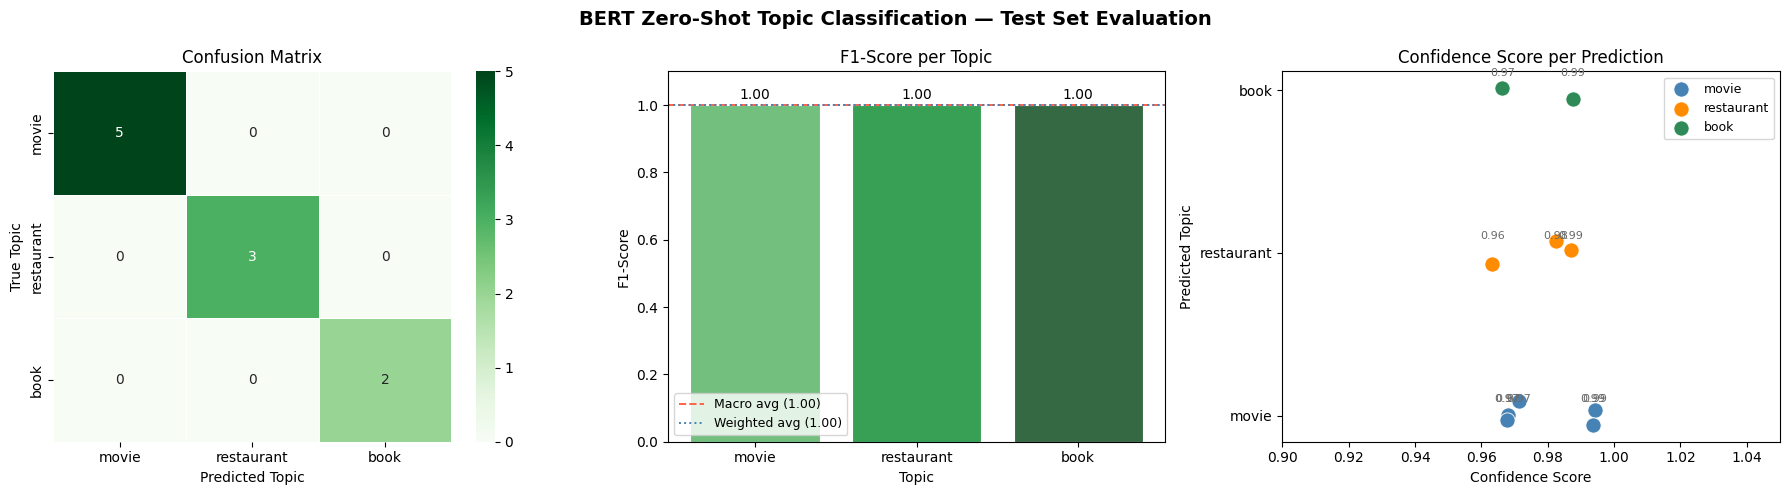


Plot saved to  → C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\topic_evaluation_plots.png


In [53]:
# ── 7. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BERT Zero-Shot Topic Classification — Test Set Evaluation", fontsize=14, fontweight="bold")

# --- Plot 1: Confusion Matrix ------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=TOPIC_LABELS)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=TOPIC_LABELS, yticklabels=TOPIC_LABELS,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Topic")
axes[0].set_ylabel("True Topic")

# --- Plot 2: Per-class F1 Bar Chart ------------------------------------------
colors = sns.color_palette("Greens_d", len(TOPIC_LABELS))
bars = axes[1].bar(TOPIC_LABELS, f1_per_class, color=colors, edgecolor="white", linewidth=0.8)
axes[1].axhline(f1_macro,    color="tomato",    linestyle="--", linewidth=1.4, label=f"Macro avg ({f1_macro:.2f})")
axes[1].axhline(f1_weighted, color="steelblue", linestyle=":",  linewidth=1.4, label=f"Weighted avg ({f1_weighted:.2f})")
for bar, val in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("F1-Score per Topic")
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)

# --- Plot 3: Confidence Score Distribution per Topic -------------------------
topic_colors = {"movie": "steelblue", "restaurant": "darkorange", "book": "seagreen"}

for i, label in enumerate(TOPIC_LABELS):
    subset = test_df[test_df["predicted_topic"] == label]
    # Add small jitter on y-axis so overlapping dots don't stack
    jitter = np.random.uniform(-0.1, 0.1, size=len(subset))
    axes[2].scatter(
        subset["predicted_topic_score"],
        [i + j for j in jitter],
        color=topic_colors[label],
        s=120, zorder=3, edgecolors="white", linewidths=0.6,
        label=label
    )
    # Annotate each dot with its score
    for _, row in subset.iterrows():
        axes[2].annotate(
            f"{row['predicted_topic_score']:.2f}",
            xy=(row["predicted_topic_score"], i),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=8, color="dimgray"
        )

axes[2].set_yticks(range(len(TOPIC_LABELS)))
axes[2].set_yticklabels(TOPIC_LABELS)
axes[2].set_xlim(0.9, 1.05)
axes[2].set_title("Confidence Score per Prediction")
axes[2].set_xlabel("Confidence Score")
axes[2].set_ylabel("Predicted Topic")
axes[2].legend(fontsize=9)

plt.tight_layout()

PLOT_PATH = r"C:\Users\keimp\Documents\GitHub\text_mining_for_AI_group3\project\sentiment-topic-results\topic_evaluation_plots.png"
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to  → {PLOT_PATH}")